# Course-end Project 2 - Sales Analysis

# Angela Johnson 

**Step 1:**

In [38]:
# loading dataset 
import pandas as pd

df = pd.read_csv("AusApparalSales4thQrt2020.csv")

In [39]:
# 1a -- Inspect missing/incorrect data
print("Check for missing values:\n")
print(df.isna().sum())

print("\nCheck for non-missing values:\n")
print(df.notna().sum())

# optional: see a few rows
print("\nFirst 5 rows of the data:\n")
print(df.head())

Check for missing values:

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Check for non-missing values:

Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

First 5 rows of the data:

         Date        Time State     Group  Unit  Sales
0  1-Oct-2020     Morning    WA      Kids     8  20000
1  1-Oct-2020     Morning    WA       Men     8  20000
2  1-Oct-2020     Morning    WA     Women     4  10000
3  1-Oct-2020     Morning    WA   Seniors    15  37500
4  1-Oct-2020   Afternoon    WA      Kids     3   7500


In [13]:
# 1b -- Recommendations
# - For numeric columns like Sales/Units, fill missing with median
# - For categorical columns like State/Group, fill missing with mode
# - Drop rows only if completely empty
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df['Unit'] = df['Unit'].fillna(df['Unit'].median())
df['State'] = df['State'].fillna(df['State'].mode()[0])
df['Group'] = df['Group'].fillna(df['Group'].mode()[0])


print(df.columns)

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')


In [14]:
# 1c -- Normalization (scales values between 0 and 1)
df['Sales_norm'] = (df['Sales'] - df['Sales'].min()) / (df['Sales'].max() - df['Sales'].min())
df['Unit_norm'] = (df['Unit'] - df['Unit'].min()) / (df['Unit'].max() - df['Unit'].min())

print("\nPreview of normalized data:\n")
print(df[['State','Group','Sales','Sales_norm','Unit','Unit_norm']].head())


Preview of normalized data:

  State     Group  Sales  Sales_norm  Unit  Unit_norm
0    WA      Kids  20000    0.095238     8   0.095238
1    WA       Men  20000    0.095238     8   0.095238
2    WA     Women  10000    0.031746     4   0.031746
3    WA   Seniors  37500    0.206349    15   0.206349
4    WA      Kids   7500    0.015873     3   0.015873


In [15]:
# 1d -- GroupBy examples

# Total sales by state
state_sales = df.groupby('State')['Sales'].sum().reset_index()
print("\nTotal Sales by State:\n")
print(state_sales)

# Total sales by group (Kids, Women, Men, Seniors)
group_sales = df.groupby('Group')['Sales'].sum().reset_index()
print("\nTotal Sales by Group:\n")
print(group_sales)

# Sales by State AND Group
state_group_sales = df.groupby(['State','Group'])['Sales'].sum().reset_index()
print("\nTotal Sales by State and Group:\n")
print(state_group_sales.head())


Total Sales by State:

  State      Sales
0   NSW   74970000
1    NT   22580000
2   QLD   33417500
3    SA   58857500
4   TAS   22760000
5   VIC  105565000
6    WA   22152500

Total Sales by Group:

      Group     Sales
0      Kids  85072500
1       Men  85750000
2   Seniors  84037500
3     Women  85442500

Total Sales by State and Group:

  State     Group     Sales
0   NSW      Kids  18587500
1   NSW       Men  19022500
2   NSW   Seniors  18187500
3   NSW     Women  19172500
4    NT      Kids   5700000


* groupby() helps with chnunking data into categories --> state or group
* can quickly see which states or customers groups generate the most sales

**Step 2:**

In [16]:
# 2a -- Descriptive statistics, sales and units

import numpy as np
from scipy import stats

# 2a -- Descriptive statistics for Sales and Unit
print("Descriptive Statistics for Sales:")
print("Mean:", df['Sales'].mean())
print("Median:", df['Sales'].median())
print("Mode:", df['Sales'].mode()[0])
print("Standard Deviation:", df['Sales'].std())

print("\nDescriptive Statistics for Unit:")
print("Mean:", df['Unit'].mean())
print("Median:", df['Unit'].median())
print("Mode:", df['Unit'].mode()[0])
print("Standard Deviation:", df['Unit'].std())

Descriptive Statistics for Sales:
Mean: 45013.5582010582
Median: 35000.0
Mode: 22500
Standard Deviation: 32253.506943966317

Descriptive Statistics for Unit:
Mean: 18.00542328042328
Median: 14.0
Mode: 9
Standard Deviation: 12.901402777586458


In [19]:
# 2b -- Group with highest and lowest sales
group_sales = df.groupby('Group')['Sales'].sum().reset_index()

highest_group = group_sales.loc[group_sales['Sales'].idxmax()]
lowest_group = group_sales.loc[group_sales['Sales'].idxmin()]

print("\nGroup with Highest Sales:\n", highest_group)
print("\nGroup with Lowest Sales:\n", lowest_group)


Group with Highest Sales:
 Group         Men
Sales    85750000
Name: 1, dtype: object

Group with Lowest Sales:
 Group     Seniors
Sales    84037500
Name: 2, dtype: object


In [20]:
# 2c -- State with highest and lowest sales
state_sales = df.groupby('State')['Sales'].sum().reset_index()

highest_state = state_sales.loc[state_sales['Sales'].idxmax()]
lowest_state = state_sales.loc[state_sales['Sales'].idxmin()]

print("\nState with Highest Sales:\n", highest_state)
print("\nState with Lowest Sales:\n", lowest_state)


State with Highest Sales:
 State          VIC
Sales    105565000
Name: 5, dtype: object

State with Lowest Sales:
 State          WA
Sales    22152500
Name: 6, dtype: object


In [21]:
# ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# set Date as index for resampling
df.set_index('Date', inplace=True)

# weekly sales report
weekly = df.resample('W')['Sales'].sum()
print("\nWeekly Sales Report:\n", weekly)

# monthly sales report
monthly = df.resample('M')['Sales'].sum()
print("\nMonthly Sales Report:\n", monthly)

# quarterly sales report
quarterly = df.resample('Q')['Sales'].sum()
print("\nQuarterly Sales Report:\n", quarterly)


Weekly Sales Report:
 Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
2020-11-08    20865000
2020-11-15    21172500
2020-11-22    21112500
2020-11-29    21477500
2020-12-06    29622500
2020-12-13    31525000
2020-12-20    31655000
2020-12-27    31770000
2021-01-03    13792500
Freq: W-SUN, Name: Sales, dtype: int64

Monthly Sales Report:
 Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64

Quarterly Sales Report:
 Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64


/var/folders/w5/rh2j_73s3q58jlzrwv4j3b_r0000gn/T/ipykernel_92410/3268450331.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M')['Sales'].sum()
/var/folders/w5/rh2j_73s3q58jlzrwv4j3b_r0000gn/T/ipykernel_92410/3268450331.py:16: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df.resample('Q')['Sales'].sum()


**Step 3:**

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")  # cleaner look

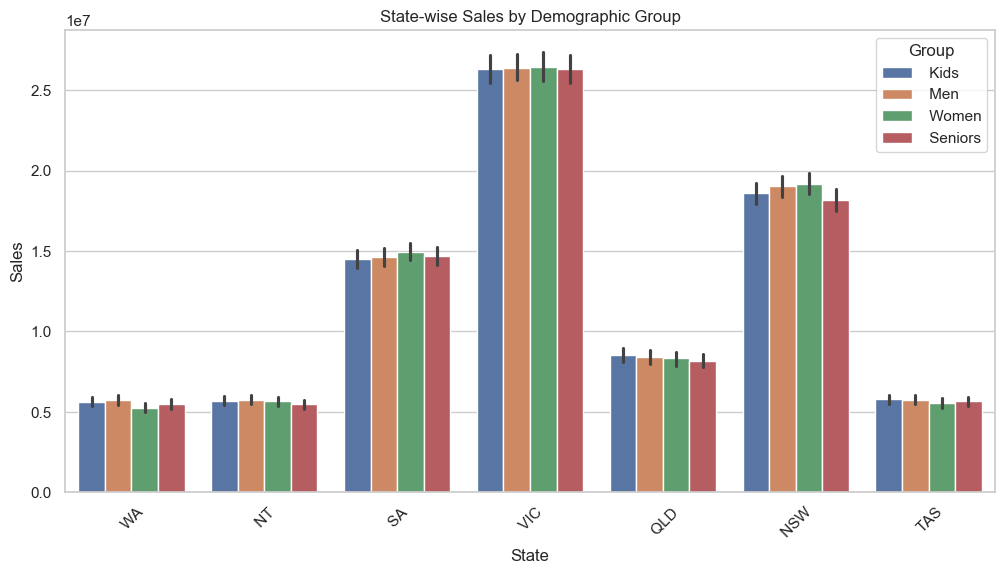

In [23]:
# 3a1 -- state × group sales
plt.figure(figsize=(12,6))
sns.barplot(data=df.reset_index(), x="State", y="Sales", hue="Group", estimator=sum)
plt.title("State-wise Sales by Demographic Group")
plt.xticks(rotation=45)
plt.show()

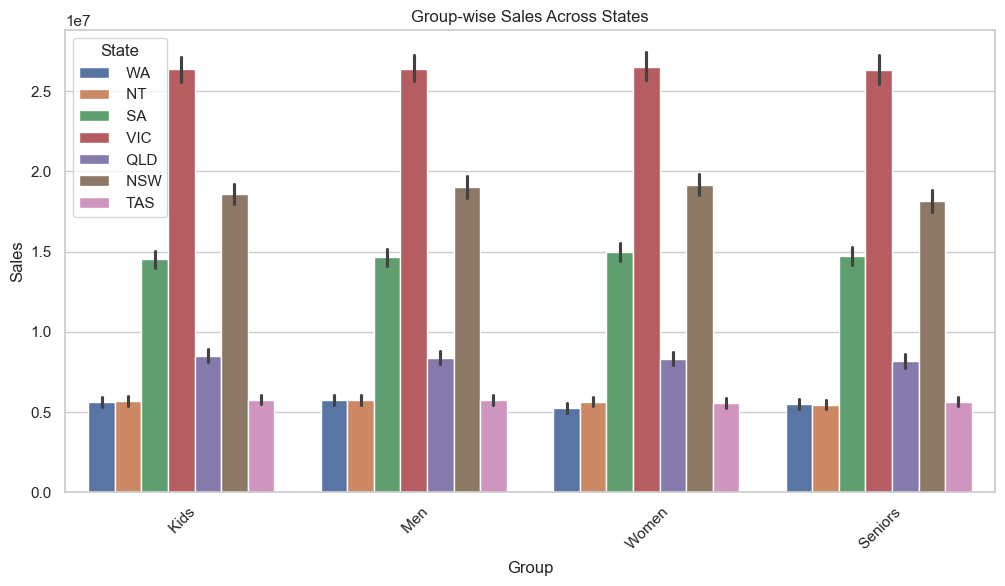

In [24]:
# 3a2 -- group × state sales (flipped view)
plt.figure(figsize=(12,6))
sns.barplot(data=df.reset_index(), x="Group", y="Sales", hue="State", estimator=sum)
plt.title("Group-wise Sales Across States")
plt.xticks(rotation=45)
plt.show()

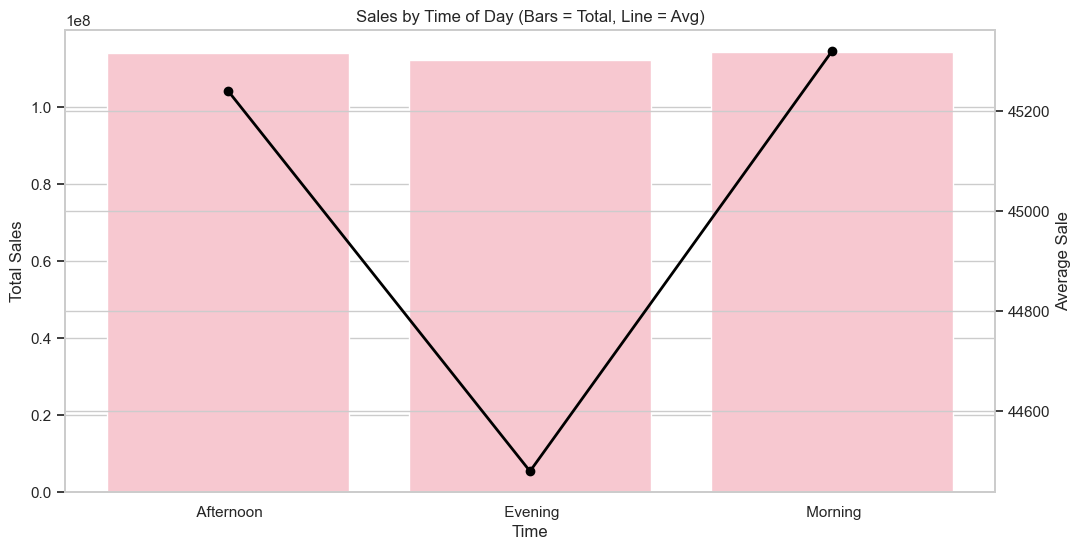

In [22]:
# 3a3 -- time-of-day sales (bars = total, line = avg)
plt.figure(figsize=(12,6))
ax = sns.barplot(data=tmp, x="Time", y="total", color="pink", errorbar=None)

# create second y-axis
ax2 = ax.twinx()
ax2.plot(tmp["Time"], tmp["avg"], marker="o", color="black", linewidth=2)

ax.set_ylabel("Total Sales")
ax2.set_ylabel("Average Sale")
plt.title("Sales by Time of Day (Bars = Total, Line = Avg)")
plt.show()

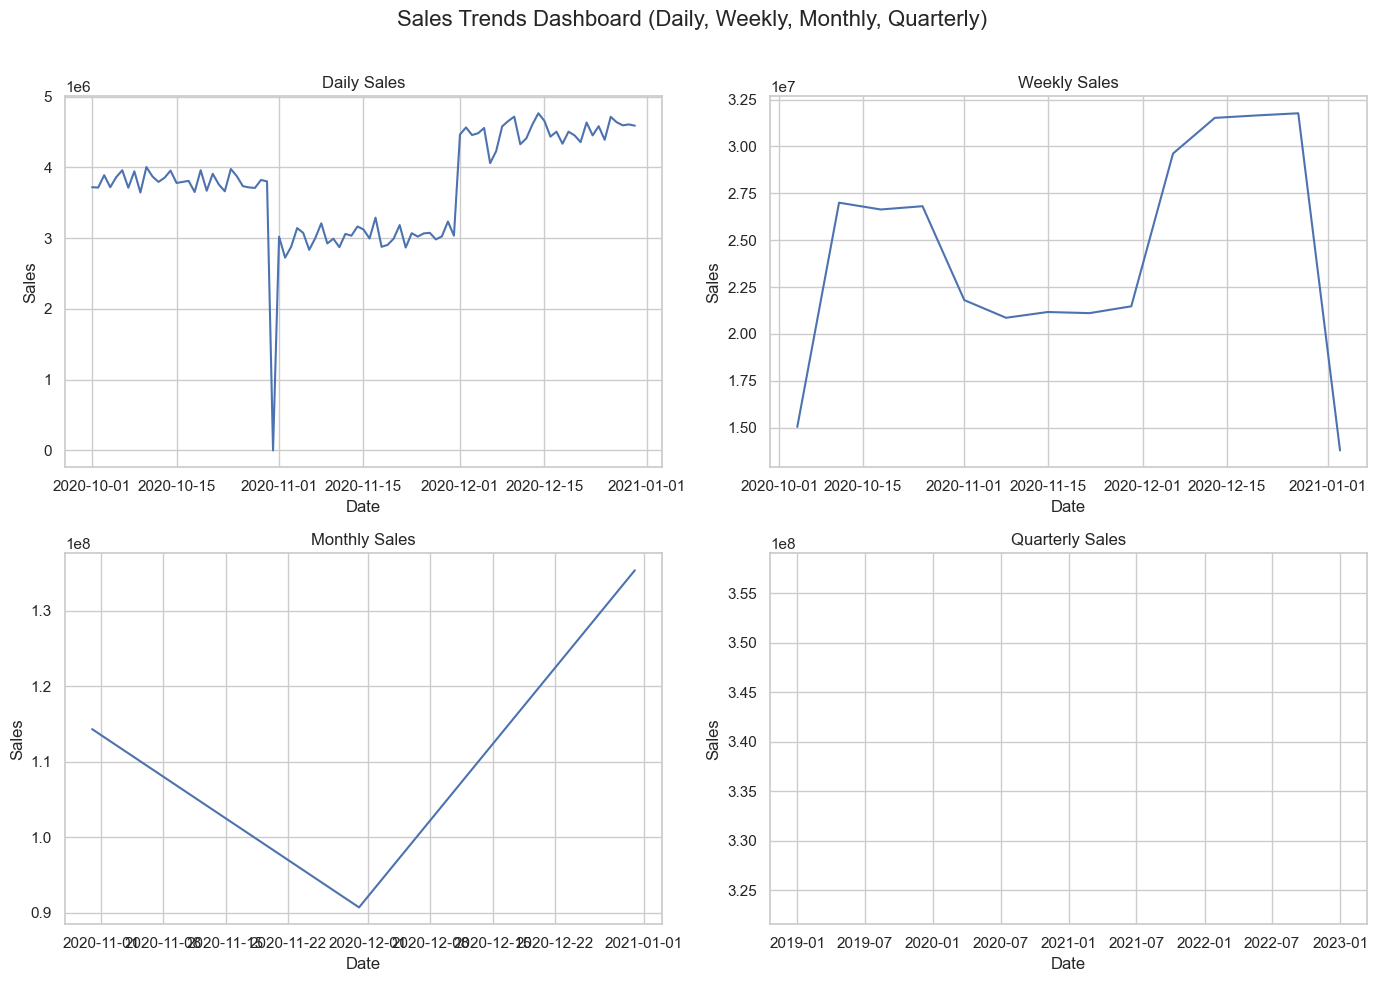

In [24]:
# 3b -- daily, weekly, monthly, quarterly sales trends
df["Date"] = pd.to_datetime(df["Date"])

# resample sales
daily = df.resample("D", on="Date")["Sales"].sum().reset_index()
weekly = df.resample("W", on="Date")["Sales"].sum().reset_index()
monthly = df.resample("ME", on="Date")["Sales"].sum().reset_index()
quarterly = df.resample("QE", on="Date")["Sales"].sum().reset_index()


# create dashboard with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharey=False)

sns.lineplot(data=daily, x="Date", y="Sales", ax=axes[0,0])
axes[0,0].set_title("Daily Sales")

sns.lineplot(data=weekly, x="Date", y="Sales", ax=axes[0,1])
axes[0,1].set_title("Weekly Sales")

sns.lineplot(data=monthly, x="Date", y="Sales", ax=axes[1,0])
axes[1,0].set_title("Monthly Sales")

sns.lineplot(data=quarterly, x="Date", y="Sales", ax=axes[1,1])
axes[1,1].set_title("Quarterly Sales")

fig.suptitle("Sales Trends Dashboard (Daily, Weekly, Monthly, Quarterly)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [25]:
#3c - my recommendation 

I ultimately chose _Seaborn_ as the primary visualization package for this dashboard because it provides clear, statistically-oriented charts. It integrates well with Pandas for resampling and grouping, while also ensuring visual consistency across daily, weekly, monthly, and quarterly sales analyses. This makes it easier for the Head of Sales and Marketing to interpret results quickly and base strategic decisions on the insights produced.

**Step 4:**

1.Report Generation

This section integrates all steps (data wrangling, analysis, and visualization) into a single JupyterLab Notebook.  
The notebook uses **Markdown** for explanations and **Seaborn/Matplotlib** for charts, ensuring clarity for the Head of Sales & Marketing.

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

**JupyterLab Integration:**

This report is created in **JupyterLab Notebook**, which enables seamless integration of:
- **Code cells** for data wrangling, analysis, and visualization  
- **Graph outputs** embedded inline  
- **Markdown cells** for narrative, findings, and recommendations

**Markdown Use:**

Throughout this report, Markdown is applied for:
- Section headers (e.g., Data Wrangling, Data Analysis, Visualization)  
- Descriptions of findings and recommendations under each plot  

**Graphs, Plots, and Analysis:**

Different graphs are used for different insights:

- **Box plot** → Descriptive statistics (spread, median, outliers)  
- **Distribution plot** → Statistical plotting (distribution, density)  
- **Line plots** → Daily/weekly/monthly/quarterly sales trends  
- **Bar plots** → State × Group, Time-of-Day analyses  


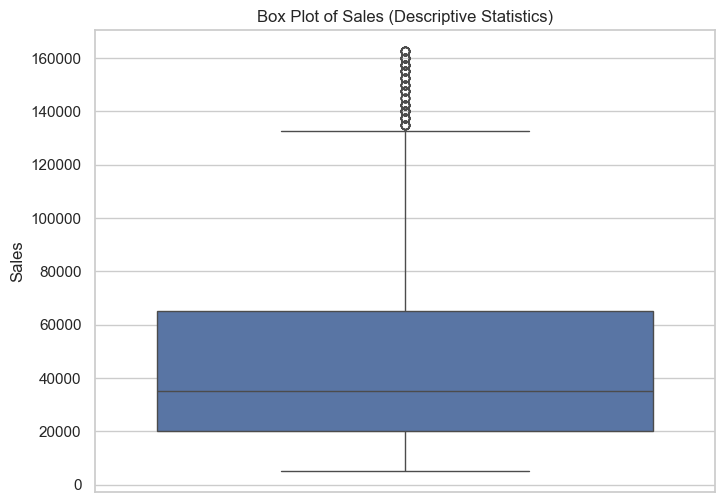

In [33]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, y="Sales")
plt.title("Box Plot of Sales (Descriptive Statistics)")
plt.show()

**Interpretation:**  
The box plot shows the spread of sales, median performance, and outliers.  
This helps identify whether sales are skewed or if a few high values drive revenue.

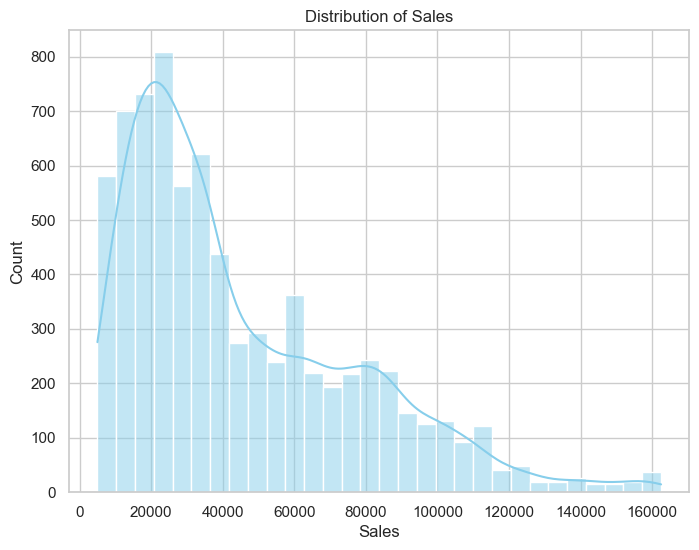

In [34]:
plt.figure(figsize=(8,6))
sns.histplot(df["Sales"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Sales")
plt.show()

**Interpretation:**  
The distribution plot shows how sales values are concentrated.  
Most transactions fall in the middle range, while fewer extreme values (outliers) exist at the higher end.

## Final Recommendations for plots
* Use _box plots_ to monitor overall stability and detect anomalies in sales.  
* Use _distribution plots_ to understand customer spending patterns.  
* Use _line plots_ (daily, weekly, monthly, quarterly) for trend planning.  
* Use _bar plots_ for clear comparison across states, groups, and time-of-day.  

## Recommendations for packages
_Visualization Package_: Seaborn is chosen because it integrates well with Pandas, produces statistically-oriented charts, and maintains consistent styling, making results easier for the Head of Sales & Marketing to interpret.